# Monte Carlo Simulation for European and Binary Option Pricing

## CQF Exam 2

**Author:** Mao Yikai  
**Date:** 2026/4/25  
**Objective:** Implement and compare numerical schemes for derivative pricing using risk-neutral valuation

---

## 1. Introduction (25%)

### 1.1 Problem Statement

The pricing of derivative securities is a fundamental problem in quantitative finance. Under the risk-neutral measure Q, the value of a derivative with payoff $\Phi(S_T)$ expiring at time $T$ is given by:

$$V(S, t) = e^{-r(T-t)} \mathbb{E}^Q[\Phi(S_T)]$$

where:
- $S$ is the underlying asset price
- $r$ is the constant risk-free interest rate
- $\mathbb{E}^Q[\cdot]$ denotes expectation under the risk-neutral measure

For derivatives without closed-form solutions, Monte Carlo simulation is a useful approach. In this project, we implement 3 numerical schemes to simulate the underlying asset price dynamics, evaluate their accuracy, and compare variance reduction techniques.

### 1.2 Geometric Brownian Motion and Black-Scholes Framework

Under the risk-neutral measure, the stock price evolves according to:

$$dS_t = rS_t dt + \sigma S_t dW_t$$

where $\sigma$ is the volatility and $W_t$ is a standard Brownian motion. The solution to this SDE is:

$$S_T = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)(T-t) + \sigma \sqrt{T-t} Z\right)$$

where $Z \sim \mathcal{N}(0,1)$ is a standard normal random variable. For European call options, the closed-form Black-Scholes formula provides:

$$C = S_0 N(d_1) - E e^{-r(T-t)} N(d_2)$$

where $d_1 = \frac{\ln(S_0/E) + (r + \sigma^2/2)(T-t)}{\sigma\sqrt{T-t}}$ and $d_2 = d_1 - \sigma\sqrt{T-t}$, with $N(\cdot)$ being the cumulative standard normal distribution (Hull, 2018).

### 1.3 Numerical Discretization Schemes

To compute the expectation numerically, we discretize the SDE over a time grid $0 = t_0 < t_1 < \ldots < t_N = T$ with step size $\Delta t = T/N$.

#### 1.3.1 Euler-Maruyama Scheme

The Euler-Maruyama scheme (Maruyama, 1955) provides the simplest approximation by discretizing the drift and diffusion terms:

$$S_{n+1} = S_n + rS_n \Delta t + \sigma S_n \Delta W_n$$

where $\Delta W_n \sim \mathcal{N}(0, \Delta t)$.

#### 1.3.2 Milstein Scheme

The Milstein scheme (Milstein, 1974) improves upon Euler-Maruyama by adding a correction term:

$$S_{n+1} = S_n + rS_n \Delta t + \sigma S_n \Delta W_n + \frac{1}{2}\sigma^2 S_n ((\Delta W_n)^2 - \Delta t)$$

This extra term captures nonlinear effects in the volatility dynamics, providing better accuracy for strong convergence in path-dependent scenarios.

#### 1.3.3 Closed Form Solution

We use the exact solution from section 1.2 to generate reference option prices via Monte Carlo. This provides a benchmark to assess the accuracy of the discretized schemes.

#### 1.3.4 Convergence Classification

The 3 schemes exhibit different convergence behaviors. We distinguish between **weak** and **strong** convergence:

- **Weak Convergence:** Convergence of expectations, $E[S_n^{\text{scheme}}] \to E[S_n^{\text{exact}}]$, relevant for option pricing. 
  - Euler-Maruyama: $O(\Delta t)$ weak order
  - Milstein: $O(\Delta t^2)$ weak order
  
- **Strong Convergence:** Convergence of sample paths, $E[|S_n^{\text{scheme}} - S_n^{\text{exact}}|] \to 0$, relevant for path-dependent options.
  - Euler-Maruyama: $O(\Delta t^{0.5})$ strong order
  - Milstein: $O(\Delta t^{1.0})$ strong order

For European options, where only the terminal payoff matters, weak convergence dominates. In practice, Monte Carlo variance ($O(N^{-0.5})$) typically dominates weak discretization bias, making higher-order weak schemes less critical than sample size (Kloeden & Platen, 1992).

We will apply these schemes to price 2 types of options with different payoff structures:

### 1.4 Option Types and Payoffs

**European Call Option:**  
$$\Phi_{EU}(S_T) = \max(S_T - E, 0)$$

**Binary Call Option (Cash-or-Nothing):**  
$$\Phi_{Binary}(S_T) = \mathbb{1}_{S_T > E}$$

### 1.5 Variance Reduction: Antithetic Variates

The antithetic variates technique (Hammersley & Handscomb, 1964) reduces Monte Carlo variance through symmetry. For each path $Z$, we generate a paired path $-Z$ and average their payoffs:

$$\hat{V}_{AV} = \frac{1}{2M} \sum_{i=1}^{M} \left[ e^{-rT} \Phi(S^{(i)}_T) + e^{-rT} \Phi(S^{(-i)}_T) \right]$$

This typically reduces variance by 50-90% for smooth payoffs, improving estimation accuracy without additional computational cost proportional to simulation count (Glasserman, 2004).

---

## 2. Implementation

### 2.1 Setup and Parameter Definition

In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# Configure plotting style
plt.style.use("seaborn-v0_8-darkgrid")
np.random.seed(42)

In [116]:
# Base case parameters
base_params = {
    "S0": 100.0,        # Initial stock price
    "E": 100.0,         # Strike price
    "T": 1.0,           # Time to expiry (years)
    "sigma": 0.20,      # Volatility (20% p.a.)
    "r": 0.05,          # Risk-free rate (5% p.a.)
}

print("=" * 30)
print("BASE CASE PARAMETERS")
print("=" * 30)
for key, value in base_params.items():
    if key == "sigma":
        print(f"{"σ":>8}: {value:>8.2%}")
    elif key == "r":
        print(f"{key:>8}: {value:>8.2%}")
    else:
        print(f"{key:>8}: {value:>8.2f}")

BASE CASE PARAMETERS
      S0:   100.00
       E:   100.00
       T:     1.00
       σ:   20.00%
       r:    5.00%


### 2.2 Numerical Scheme Implementations

In [117]:
def euler_maruyama(S0: float, r: float, sigma: float, T: float, 
                   n_sims: int, n_steps: int) -> np.ndarray:
    """
    Simulate stock price paths using Euler-Maruyama discretization.
    
    Parameters:
        S0 (float)
        r (float)
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (years)
        n_sims (int): Number of simulation paths
        n_steps (int): Number of time discretization steps
        
    Return:
        np.ndarray: Terminal stock prices of shape (n_sims,)
    """
    dt = T / n_steps
    dW = np.sqrt(dt) * np.random.randn(n_sims, n_steps)
    drift_coef = r * dt
    
    S = np.zeros((n_sims, n_steps + 1))
    S[:, 0] = S0
    
    for i in range(n_steps):
        diffusion_coef = sigma * dW[:, i]

        S[:, i + 1] = S[:, i] * (1 + drift_coef + diffusion_coef)
    
    return S[:, -1]

In [118]:
def milstein(S0: float, r: float, sigma: float, T: float, 
             n_sims: int, n_steps: int) -> np.ndarray:
    """
    Simulate stock price paths using Milstein discretization.
    
    Parameters:
        S0 (float)
        r (float)
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (years)
        n_sims (int): Number of simulation paths
        n_steps (int): Number of time discretization steps
        
    Return:
        np.ndarray: Terminal stock prices of shape (n_sims,)
    """
    dt = T / n_steps
    dW = np.sqrt(dt) * np.random.randn(n_sims, n_steps)
    drift_coef = r * dt
    
    S = np.zeros((n_sims, n_steps + 1))
    S[:, 0] = S0
    
    for i in range(n_steps):
        diffusion_coef = sigma * dW[:, i]
        correction_coef = 0.5 * (sigma ** 2) * (dW[:, i] ** 2 - dt)
        
        S[:, i + 1] = S[:, i] * (1 + drift_coef + diffusion_coef + correction_coef)
    
    return S[:, -1]

In [119]:
def GBM_solution(S0: float, r: float, sigma: float, T: float, 
                       n_sims: int) -> np.ndarray:
    """
    Get terminal stock prices using exact GBM solution.
    
    Parameters:
        S0 (float)
        r (float)
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (years)
        n_sims (int): Number of simulation paths
        n_steps (int): Number of time discretization steps
        
    Return:
        np.ndarray: Terminal stock prices of shape (n_sims,)
    """
    Z = np.random.randn(n_sims)
    drift = (r - 0.5 * (sigma ** 2)) * T
    diffusion = sigma * np.sqrt(T) * Z
    
    return S0 * np.exp(drift + diffusion)

### 2.3 Payoff and Pricing Functions

In [120]:
def european_call_payoff(S: np.ndarray, E: float) -> np.ndarray:
    """
    Compute European call option payoff at maturity.
    
    Parameters:
        S (np.ndarray): Terminal stock prices
        E (float): Strike price
        
    Return:
        np.ndarray: Option payoffs
    """
    return np.maximum(S - E, 0)

In [121]:
def binary_call_payoff(S: np.ndarray, E: float) -> np.ndarray:
    """
    Compute binary call option payoff at maturity.
    
    Parameters:
        S (np.ndarray): Terminal stock prices
        E (float): Strike price
        
    Return:
        np.ndarray: Binary payoffs (0 or 1)
    """
    return (S > E).astype(int)

In [122]:
def monte_carlo_price(payoffs: np.ndarray, discount_factor: float) -> tuple:
    """
    Estimate option price from Monte Carlo payoffs.
    
    Parameters:
        payoffs (np.ndarray): Payoffs across all simulation paths
        discount_factor (float): exp(-r * T)
        
    Return:
        tuple: (price, std_error)
    """
    price = discount_factor * np.mean(payoffs)
    # Standard error of price estimate
    std_error = discount_factor * np.std(payoffs) / np.sqrt(len(payoffs))
    
    return price, std_error

In [123]:
def euler_maruyama_antithetic(S0: float, r: float, sigma: float, T: float, 
                              n_sims: int, n_steps: int) -> tuple:
    """
    Simulate paths using Euler-Maruyama with antithetic variates.
    For each random vector Z, generate both Z and -Z paths.
    
    Parameters:
        S0 (float)
        r (float)
        sigma (float): Volatility (annualized)
        T (float): Time to maturity (years)
        n_sims (int): Number of simulation paths
        n_steps (int): Number of time discretization steps
        
    Return:
        tuple: (S_positive, S_negative), and each has shape (n_sims,)
    """
    dt = T / n_steps
    dW = np.sqrt(dt) * np.random.randn(n_sims, n_steps)
    drift_coef = r * dt
    
    # Positive paths
    S_pos = np.zeros((n_sims, n_steps + 1))
    S_pos[:, 0] = S0
    for i in range(n_steps):
        diffusion_coef = sigma * dW[:, i]

        S_pos[:, i + 1] = S_pos[:, i] * (1 + drift_coef + diffusion_coef)
    
    # Negative (antithetic) paths
    S_neg = np.zeros((n_sims, n_steps + 1))
    S_neg[:, 0] = S0
    for i in range(n_steps):
        diffusion_coef = sigma * dW[:, i]

        S_neg[:, i + 1] = S_neg[:, i] * (1 + drift_coef - diffusion_coef)
    
    return S_pos[:, -1], S_neg[:, -1]

### 2.4 Black-Scholes Reference Formula

In [124]:
def black_scholes_call(S0: float, E: float, T: float, r: float, 
                       sigma: float) -> float:
    """
    Compute European call option price using Black-Scholes formula.
    
    
    Parameters:
        S0 (float)
        E (float)
        T (float): Time to maturity (years)
        r (float)
        sigma (float): Volatility (annualized)
    
    Return:
        float: European call option price
    """
    sqrt_T = np.sqrt(T)
    d1 = (np.log(S0 / E) + (r + 0.5 * (sigma ** 2)) * T) / (sigma * sqrt_T)
    d2 = d1 - sigma * sqrt_T
    
    call_price = S0 * norm.cdf(d1) - E * np.exp(-r * T) * norm.cdf(d2)
    
    return call_price

In [125]:
# Compute Black-Scholes reference price
bs_price = black_scholes_call(
    S0=base_params["S0"], 
    E=base_params["E"], 
    T=base_params["T"], 
    r=base_params["r"], 
    sigma=base_params["sigma"]
)

print(f"Black-Scholes European Call Price: ${bs_price:.4f}")

Black-Scholes European Call Price: $10.4506


---

## 3. Results (40%)

### 3.1 Base Case: Default Parameters

In this section, we price European and binary call options using the default parameter set:

$$S_0 = 100, E = 100, T = 1 \text{ year}, \sigma = 20\%, r = 5\%$$

In [126]:
# Base case pricing with varying simulation counts
sim_cnts = [10_000, 50_000, 100_000, 500_000, 1_000_000]
n_steps = 252  # Daily steps over 1 year

discount_factor = np.exp(-base_params["r"] * base_params["T"])

results_eu = []
results_bin = []

#### 3.1.1 European Call Pricing Results
We now compare the 3 numerical schemes for European call option pricing across different simulation counts:

In [127]:
# European call pricing
print("=" * 70)
print("BASE CASE PRICING: EUROPEAN CALL OPTION")
print("=" * 70)

for n_sims in sim_cnts:
    # Euler-Maruyama
    S_em = euler_maruyama(base_params["S0"], base_params["r"], base_params["sigma"], 
                          base_params["T"], n_sims, n_steps)
    payoff_em = european_call_payoff(S_em, base_params["E"])
    price_em, std_error_em = monte_carlo_price(payoff_em, discount_factor)
    error_em = abs(price_em - bs_price)
    
    results_eu.append({
        "Simulations": n_sims,
        "Method": "Euler-Maruyama",
        "Price": price_em,
        "Error": error_em,
        "Std_Error": std_error_em
    })
    
    # Milstein
    S_mil = milstein(base_params["S0"], base_params["r"], base_params["sigma"], 
                     base_params["T"], n_sims, n_steps)
    payoff_mil = european_call_payoff(S_mil, base_params["E"])
    price_mil, std_error_mil = monte_carlo_price(payoff_mil, discount_factor)
    error_mil = abs(price_mil - bs_price)
    
    results_eu.append({
        "Simulations": n_sims,
        "Method": "Milstein",
        "Price": price_mil,
        "Error": error_mil,
        "Std_Error": std_error_mil
    })
    
    # Analytical
    S_gbm = GBM_solution(base_params["S0"], base_params["r"], base_params["sigma"], 
                               base_params["T"], n_sims)
    payoff_gbm = european_call_payoff(S_gbm, base_params["E"])
    price_gbm, se_gbm = monte_carlo_price(payoff_gbm, discount_factor)
    error_gbm = abs(price_gbm - bs_price)
    
    results_eu.append({
        "Simulations": n_sims,
        "Method": "Analytical",
        "Price": price_gbm,
        "Error": error_gbm,
        "Std_Error": se_gbm
    })

df_eu_results = pd.DataFrame(results_eu)

# Display European call results table
df_eu_display = df_eu_results.copy()
df_eu_display["Simulations"] = df_eu_display["Simulations"].apply(lambda x: f"{x:,}")
df_eu_display["Price"] = df_eu_display["Price"].apply(lambda x: f"{x:.6f}")
df_eu_display["Error"] = df_eu_display["Error"].apply(lambda x: f"{x:.6f}")
df_eu_display["Std_Error"] = df_eu_display["Std_Error"].apply(lambda x: f"{x:.6f}")

display(df_eu_display)
print(f"Black-Scholes Reference Price: ${bs_price:.6f}")

BASE CASE PRICING: EUROPEAN CALL OPTION


,Simulations,Method,Price,Error,Std_Error
0,"10,000",Euler-Maruyama,10.217317,0.233267,0.144506
1,"10,000",Milstein,10.342466,0.108117,0.146301
2,"10,000",Analytical,10.174797,0.275787,0.143225
3,"50,000",Euler-Maruyama,10.437541,0.013043,0.065427
4,"50,000",Milstein,10.343164,0.107420,0.065102
5,"50,000",Analytical,10.422152,0.028432,0.065707
6,"100,000",Euler-Maruyama,10.346747,0.103836,0.046307
7,"100,000",Milstein,10.330094,0.120490,0.046195
8,"100,000",Analytical,10.513432,0.062849,0.046650
9,"500,000",Euler-Maruyama,10.443313,0.007270,0.020819


Black-Scholes Reference Price: $10.450584


**Table 1:** European Call Option Pricing Comparison Across Simulation Methods and Counts

The table above presents the estimated option prices, absolute errors relative to the Black-Scholes benchmark, and standard errors for 3 numerical schemes (Euler-Maruyama, Milstein, and Analytical) across varying simulation counts (10,000 to 1,000,000 paths).

#### 3.1.2 Binary Call Pricing Results
We now compare the 3 numerical schemes for binary call option pricing across different simulation counts:

In [128]:
# Binary call pricing
print("=" * 70)
print("BASE CASE PRICING: BINARY CALL OPTION")
print("=" * 70)

for n_sims in sim_cnts:
    # Euler-Maruyama
    S_em = euler_maruyama(base_params["S0"], base_params["r"], base_params["sigma"], 
                          base_params["T"], n_sims, n_steps)
    payoff_em = binary_call_payoff(S_em, base_params["E"])
    price_em, std_error_em = monte_carlo_price(payoff_em, discount_factor)
    
    results_bin.append({
        "Simulations": n_sims,
        "Method": "Euler-Maruyama",
        "Price": price_em,
        "Std_Error": std_error_em
    })
    
    # Milstein
    S_mil = milstein(base_params["S0"], base_params["r"], base_params["sigma"], 
                     base_params["T"], n_sims, n_steps)
    payoff_mil = binary_call_payoff(S_mil, base_params["E"])
    price_mil, std_error_mil = monte_carlo_price(payoff_mil, discount_factor)
    
    results_bin.append({
        "Simulations": n_sims,
        "Method": "Milstein",
        "Price": price_mil,
        "Std_Error": std_error_mil
    })
    
    # Analytical
    S_gbm = GBM_solution(base_params["S0"], base_params["r"], base_params["sigma"], 
                               base_params["T"], n_sims)
    payoff_gbm = binary_call_payoff(S_gbm, base_params["E"])
    price_gbm, std_error_gbm = monte_carlo_price(payoff_gbm, discount_factor)
    
    results_bin.append({
        "Simulations": n_sims,
        "Method": "Analytical",
        "Price": price_gbm,
        "Std_Error": std_error_gbm
    })

df_bin_results = pd.DataFrame(results_bin)

# Display Binary call results table
df_bin_display = df_bin_results.copy()
df_bin_display["Simulations"] = df_bin_display["Simulations"].apply(lambda x: f"{x:,}")
df_bin_display["Price"] = df_bin_display["Price"].apply(lambda x: f"{x:.6f}")
df_bin_display["Std_Error"] = df_bin_display["Std_Error"].apply(lambda x: f"{x:.6f}")

display(df_bin_display)

BASE CASE PRICING: BINARY CALL OPTION


,Simulations,Method,Price,Std_Error
0,"10,000",Euler-Maruyama,0.533259,0.004721
1,"10,000",Milstein,0.534020,0.004720
2,"10,000",Analytical,0.536779,0.004717
3,"50,000",Euler-Maruyama,0.533088,0.002111
4,"50,000",Milstein,0.534629,0.002111
5,"50,000",Analytical,0.531452,0.002112
6,"100,000",Euler-Maruyama,0.531509,0.001494
7,"100,000",Milstein,0.531775,0.001494
8,"100,000",Analytical,0.536531,0.001492
9,"500,000",Euler-Maruyama,0.532517,0.000668


**Table 2:** Binary Call Option Pricing Comparison Across Simulation Methods and Counts

The table above presents the estimated option prices and standard errors for 3 numerical schemes (Euler-Maruyama, Milstein, and Analytical) across varying simulation counts (10,000 to 1,000,000 paths).

#### 3.1.3 Summary & Error Comparison

In [129]:
# Summary table for results comparison
print("=" * 70)
print("RESULTS SUMMARY: BASE CASE COMPARISON AT 1,000,000 SIMULATIONS")
print("=" * 70)

# Create summary table for European call
summary_eu = []

for method in ["Euler-Maruyama", "Milstein", "Analytical"]:
    row = df_eu_results[df_eu_results["Method"] == method].iloc[-1]  # Last (highest sim count)
    summary_eu.append({
        "Method": method,
        "Price (MC)": row["Price"],
        "Error vs BS": row["Error"],
        "Std Error": row["Std_Error"],
        "95% CI Width": 1.96 * row["Std_Error"]
    })

df_summary_eu = pd.DataFrame(summary_eu)

print("\nEUROPEAN CALL OPTION:")
print(f"{'Method':<18} {'MC Price':<12} {'Error ($)':<12} {'Std Error':<12} {'95% CI Width':<12}")
print("-" * 70)

for _, row in df_summary_eu.iterrows():
    print(f"{row['Method']:<18} ${row['Price (MC)']:<11.6f} ${row['Error vs BS']:<11.6f} ${row['Std Error']:<11.6f} ${row['95% CI Width']:<11.6f}")
print(f"\nBlack-Scholes Reference: ${bs_price:.6f}")

# Create summary table for Binary call
summary_bin = []

for method in ["Euler-Maruyama", "Milstein", "Analytical"]:
    row = df_bin_results[df_bin_results["Method"] == method].iloc[-1]  # Last (highest sim count)
    summary_bin.append({
        "Method": method,
        "Price (MC)": row["Price"],
        "Std Error": row["Std_Error"],
        "95% CI Width": 1.96 * row["Std_Error"]
    })

df_summary_bin = pd.DataFrame(summary_bin)

print("\n\n\nBINARY CALL OPTION:")
print(f"{'Method':<18} {'MC Price':<12} {'Std Error':<12} {'95% CI Width':<12}")
print("-" * 70)

for _, row in df_summary_bin.iterrows():
    print(f"{row['Method']:<18} ${row['Price (MC)']:<11.6f} ${row['Std Error']:<11.6f} ${row['95% CI Width']:<11.6f}")


RESULTS SUMMARY: BASE CASE COMPARISON AT 1,000,000 SIMULATIONS

EUROPEAN CALL OPTION:
Method             MC Price     Error ($)    Std Error    95% CI Width
----------------------------------------------------------------------
Euler-Maruyama     $10.449395   $0.001188    $0.014682    $0.028776   
Milstein           $10.449198   $0.001385    $0.014721    $0.028854   
Analytical         $10.457201   $0.006617    $0.014725    $0.028861   

Black-Scholes Reference: $10.450584



BINARY CALL OPTION:
Method             MC Price     Std Error    95% CI Width
----------------------------------------------------------------------
Euler-Maruyama     $0.531733    $0.000472    $0.000926   
Milstein           $0.531830    $0.000472    $0.000926   
Analytical         $0.532561    $0.000472    $0.000925   


Using the base-case setting ($N=1{,}000{,}000$, $n_{steps}=252$), the summary table reports the following:

- **European call:** all 3 methods produce close prices, and absolute errors versus Black-Scholes remain small (about $0.0012$-$0.0066$).
- **Binary call:** method prices are also close (spread about $0.00083$), with tight uncertainty bands.

Uncertainty is interpreted through

$$\text{CI}_{95\%}=\text{Price}\pm1.96\times\text{SE},$$

where 95% CI widths are about $0.0288$ (European) and $0.00093$ (Binary) in this run.

Overall, this base-case snapshot indicates limited cross-method differences at high path count, while the main reported uncertainty is sampling-based.

### 3.2 Convergence Analysis

CONVERGENCE ANALYSIS: EUROPEAN CALL OPTION


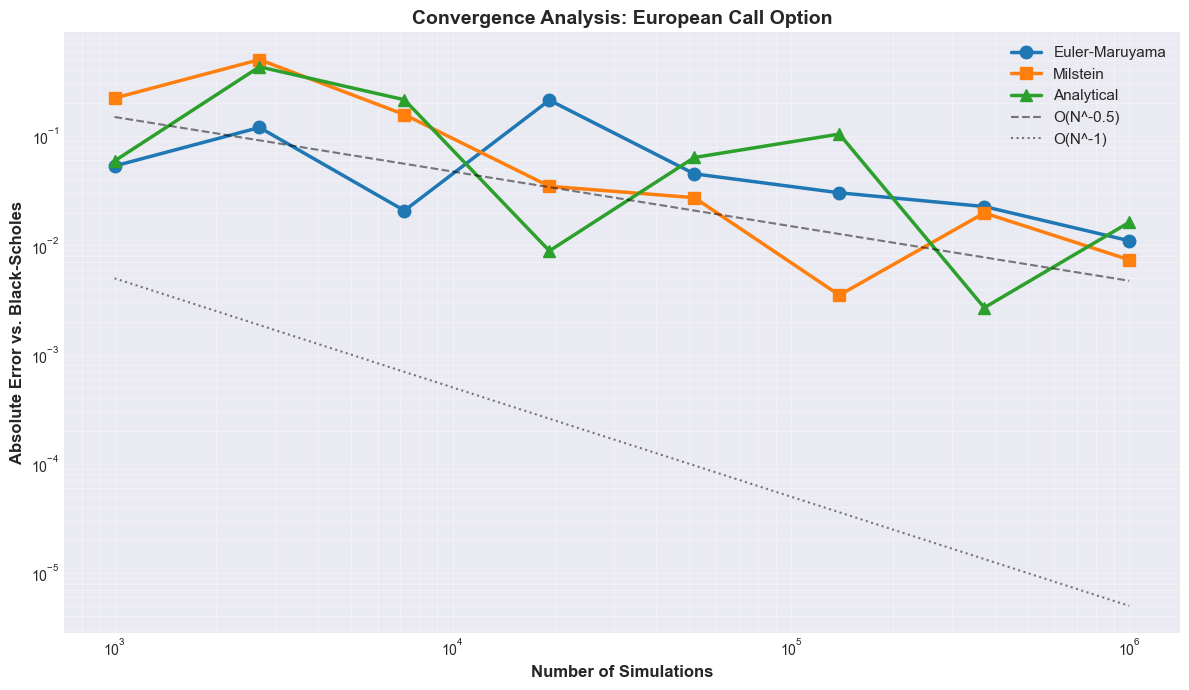

In [131]:
# Convergence analysis with optimized parameters for faster execution
# Use 8 simulation points from 1k to 1M paths
sim_range = np.logspace(3, 6, 8, dtype=int)
# Reduced to 100 time steps for computational efficiency
n_steps = 100
FIGSIZE = (12, 7)

# European call convergence
print("=" * 70)
print("CONVERGENCE ANALYSIS: EUROPEAN CALL OPTION")
print("=" * 70)

errors_eu_em = []
errors_eu_mil = []
errors_eu_gbm = []

for n_sims in sim_range:
    # Euler-Maruyama scheme
    S = euler_maruyama(base_params["S0"], base_params["r"], base_params["sigma"], 
                       base_params["T"], n_sims, n_steps)
    price_em, _ = monte_carlo_price(european_call_payoff(S, base_params["E"]), discount_factor)
    errors_eu_em.append(abs(price_em - bs_price))
    
    # Milstein scheme
    S = milstein(base_params["S0"], base_params["r"], base_params["sigma"], 
                 base_params["T"], n_sims, n_steps)
    price_mil, _ = monte_carlo_price(european_call_payoff(S, base_params["E"]), discount_factor)
    errors_eu_mil.append(abs(price_mil - bs_price))
    
    # Analytical solution (exact reference)
    S = GBM_solution(base_params["S0"], base_params["r"], base_params["sigma"], 
                     base_params["T"], n_sims)
    price_gbm, _ = monte_carlo_price(european_call_payoff(S, base_params["E"]), discount_factor)
    errors_eu_gbm.append(abs(price_gbm - bs_price))

# Plot convergence analysis
fig, ax = plt.subplots(figsize=FIGSIZE)

# Plot convergence curves for each scheme
ax.loglog(sim_range, errors_eu_em, "o-", label="Euler-Maruyama", linewidth=2.5, markersize=9)
ax.loglog(sim_range, errors_eu_mil, "s-", label="Milstein", linewidth=2.5, markersize=9)
ax.loglog(sim_range, errors_eu_gbm, "^-", label="Analytical", linewidth=2.5, markersize=9)

# Add reference convergence rate lines
ref_x = np.array([sim_range[0], sim_range[-1]])
# O(N^-0.5) reference line
ax.loglog(ref_x, 0.15 * (ref_x / sim_range[0])**(-0.5), "k--", alpha=0.5, linewidth=1.5, label="O(N^-0.5)")
# O(N^-1) reference line for comparison
ax.loglog(ref_x, 0.005 * (ref_x / sim_range[0])**(-1.0), "k:", alpha=0.5, linewidth=1.5, label="O(N^-1)")

ax.set_xlabel("Number of Simulations", fontsize=12, fontweight="bold")
ax.set_ylabel("Absolute Error vs. Black-Scholes", fontsize=12, fontweight="bold")
ax.set_title("Convergence Analysis: European Call Option", fontsize=14, fontweight="bold")
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

From the log-log plot, all 3 schemes show a broadly decreasing error trend as simulation count increases. In the higher-simulation region, the slopes are close to the $O(N^{-0.5})$ reference, indicating that Monte Carlo sampling error dominates. Milstein can be a little better than Euler at some intermediate points, but the gap is small relative to sampling noise. Overall, in this setup, increasing path count is the most direct way to improve pricing accuracy.